In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import sys, os, tqdm, glob
wdmodels_dir = os.environ['WDMODELS_DIR']
sys.path.append(wdmodels_dir)
import WD_models

mass_sun, radius_sun, newton_G = 1.9884e30, 6.957e8, 6.674e-11
font_model = WD_models.load_model("bet", "be", "ONe", "H")
g_acc = (10**font_model["logg"]) / 100.0
rsun = np.sqrt(font_model["mass_array"] * mass_sun * newton_G / g_acc) / radius_sun

_G_AGE_BET = WD_models.interp_xy_z_func(
    x = font_model['age_cool'], y = font_model["mass_array"],
    z = 10**font_model['logteff'], 
    interp_type = 'linear'
)

In [21]:
ifmr = pd.read_csv("../data/MESA_IFMR/MESA_IFMR_missing_one_point.csv")
mi = np.load("../data/MESA_IFMR/mi.npy")
ms_life = np.load("../data/MESA_IFMR/msl.npy")

ifmr["mslifetime"] = np.interp(ifmr["M_initial"], mi, ms_life)
ifmr["cooling_budget"] = 13-ifmr.mslifetime
ifmr["teff_max"] = _G_AGE_BET(ifmr["cooling_budget"], ifmr["M_final"])
ifmr.to_csv("../data/MESA_IFMR/ifmr_data.csv")

Text(0.5, 0, 'Maximum Possible Temperature [K]')

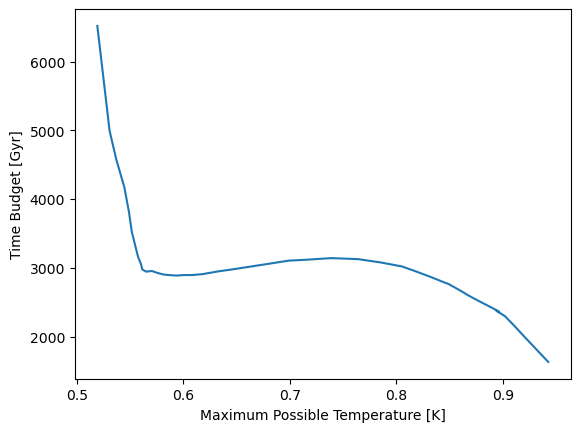

In [22]:
plt.plot(ifmr.M_final, ifmr.teff_max)
plt.ylabel("Time Budget [Gyr]")
plt.xlabel("Maximum Possible Temperature [K]")